In [1]:
import sys
from pathlib import Path
import torch
import numpy as np

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT, XLSR_DROPOUT, RANDOM_SEEDS
from model_DANN import AD_XLSR_Model_DANN
from dataset import FeatureDataset, create_dataloaders
from train_ST_DANN import train_st_dann_parallel, validate_dann
from visualization import plot_training_curves, plot_dataset_comparison

2026-01-19 04:34:10 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


In [2]:
SOURCE_DATASET = "ADReSS"
TARGET_DATASET = "Lu"

# Model Selection Weights
SOURCE_WEIGHT = 0.5  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.5  # Weight for target domain validation accuracy

# Accuracy Thresholds
MIN_SOURCE_ACC = 0  # Minimum required source domain validation accuracy
MIN_TARGET_ACC = 0  # Minimum required target domain validation accuracy

# Training Hyperparameters

MAX_ITERATIONS = 10              # Maximum ST iterations
MAX_EPOCHS_PER_ITER = 60        # Max epochs per ST iteration
CONFIDENCE_THRESHOLD = 0.9      # Pseudo-label confidence threshold
MIN_PSEUDO_SAMPLES = 5          # Minimum pseudo-labeled samples required

# DANN Hyperparameters
DOMAIN_WARMUP_EPOCHS = 30       # Domain loss warmup epochs (lambda=0)
DOMAIN_ANNEAL_RATIO = 0.25      # Proportion of epochs for annealing
LAMBDA_CLASS = 1.0              # Classification loss weight

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Device: {device}")

Device: cuda


In [3]:
WARMUP_EPOCHS = 20              # Warmup phase epochs (DANN on source only)
LAMBDA_DOMAIN = 1.5             # Domain adversarial loss weight

In [4]:
# ============= Feature Extraction Configuration =============
# Set to True to extract features using finetuned XLSR
EXTRACT_FEATURES = True

# Feature extraction settings
USE_FINETUNED_XLSR = True  # True: use finetuned XLSR, False: use original
FINETUNED_MODEL_PATH = f"/root/autodl-tmp/models/{SOURCE_DATASET}-finetuned-xlsr.pth"
RAW_AUDIO_DIR = Path(f"/root/autodl-tmp/data/raw/{SOURCE_DATASET}")

# Output configuration
if USE_FINETUNED_XLSR:
    FEATURE_DIR_NAME = f"{SOURCE_DATASET}_xlsr_finetuned_features"
    CSV_SUFFIX = "finetuned"
else:
    FEATURE_DIR_NAME = f"{SOURCE_DATASET}_xlsr_features"
    CSV_SUFFIX = ""

In [5]:
# ============= Execute Feature Extraction =============
if EXTRACT_FEATURES:
    print("Starting feature extraction...\n")

    from extract_XLSR_feature import extract_features_from_csv
    from model import SSLModel
    import csv

    # Step 1: Initialize SSLModel with optional finetuned weights
    print("Initializing XLSR model...")
    ssl_model = SSLModel(
        device=device,
        freeze_xlsr=True,
        finetuned_model_path=FINETUNED_MODEL_PATH if USE_FINETUNED_XLSR else None
    )
    print()

    # Step 2: Use existing CSV files to extract features
    data_dir = Path("/root/autodl-tmp/data/processed")

    # CSV files already exist, use them directly
    train_csv_path = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
    val_csv_path = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"

    # Features saved to new directory
    xlsr_features_dir = data_dir / FEATURE_DIR_NAME

    print(f"Using existing CSV files:")
    print(f"  Train: {train_csv_path.name}")
    print(f"  Val: {val_csv_path.name}")
    print(f"Extracting features to: {xlsr_features_dir}\n")

    # Step 3: Extract features using the existing function
    print(f"Processing train set...")
    extract_features_from_csv(
        csv_path=train_csv_path,
        split_name=f"{SOURCE_DATASET}-train",
        raw_audio_dir=RAW_AUDIO_DIR,
        xlsr_features_dir=xlsr_features_dir,
        device=device,
        ssl_model=ssl_model,  # Pass the initialized model
        freeze_xlsr=True
    )

    print(f"\nProcessing validation set...")
    extract_features_from_csv(
        csv_path=val_csv_path,
        split_name=f"{SOURCE_DATASET}-val",
        raw_audio_dir=RAW_AUDIO_DIR,
        xlsr_features_dir=xlsr_features_dir,
        device=device,
        ssl_model=ssl_model,  # Pass the same model
        freeze_xlsr=True
    )

    # Step 4: Update CSV files to point to new features
    print(f"\nUpdating CSV files to point to new features...")
    for csv_file in [train_csv_path, val_csv_path]:
        # Read CSV
        with open(csv_file, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        # Update xlsr_path column
        for row in rows:
            session_id = row['session_id']
            row['xlsr_path'] = f"{FEATURE_DIR_NAME}/{session_id}.xlsr.pt"

        # Write back CSV
        with open(csv_file, 'w', encoding='utf-8', newline='') as f:
            fieldnames = ['session_id', 'xlsr_path', 'ad']
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

        print(f"  Updated: {csv_file.name}")

    print(f"\n{'='*60}")
    print(f"Feature extraction complete!")
    print(f"Features saved to: {xlsr_features_dir}")
    print(f"CSV files updated to use new features")
    print(f"{'='*60}\n")

    # Clean up GPU memory
    torch.cuda.empty_cache()

else:
    print("Feature extraction skipped (EXTRACT_FEATURES=False)\n")

Starting feature extraction...

Initializing XLSR model...
XLSR: Loading base model structure


/root/miniconda3/envs/xlsr_env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Loading finetuned weights from /root/autodl-tmp/models/ADReSS-finetuned-xlsr.pth
XLSR: ✓ Loaded finetuned model from epoch 29
XLSR: ✓ Best validation accuracy: 84.38%

Using existing CSV files:
  Train: ADReSS-xlsr-train.csv
  Val: ADReSS-xlsr-val.csv
Extracting features to: /root/autodl-tmp/data/processed/ADReSS_xlsr_finetuned_features

Processing train set...

============= Extracting XLSR features for ADReSS-train =============
124 Audio Files


Extracting ADReSS-train:   0%|          | 0/124 [00:00<?, ?it/s]

Successfully extracted: 0
Already exists (skipped): 124
Errors: 0
Total: 124

Processing validation set...

============= Extracting XLSR features for ADReSS-val =============
32 Audio Files


Extracting ADReSS-val:   0%|          | 0/32 [00:00<?, ?it/s]

Successfully extracted: 0
Already exists (skipped): 32
Errors: 0
Total: 32

Updating CSV files to point to new features...
  Updated: ADReSS-xlsr-train.csv
  Updated: ADReSS-xlsr-val.csv

Feature extraction complete!
Features saved to: /root/autodl-tmp/data/processed/ADReSS_xlsr_finetuned_features
CSV files updated to use new features



In [6]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-xlsr-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-xlsr-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"ST_DANN_parallel_{SOURCE_DATASET}_to_{TARGET_DATASET}_xlsr_finetuned_t{int(CONFIDENCE_THRESHOLD*100)}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output: {MODEL_OUTPUT_DIR}")

Output: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_finetuned_t90


In [7]:
# Load datasets
source_train_dataset = FeatureDataset(SOURCE_TRAIN_CSV, xlsr=True)
target_train_dataset = FeatureDataset(TARGET_TRAIN_CSV, xlsr=True)

source_val_loader = create_dataloaders(SOURCE_VAL_CSV, xlsr=True)
target_val_loader = create_dataloaders(TARGET_VAL_CSV, xlsr=True)

Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 32 samples
Control: 16, Dementia: 16


Loading completed: 16 samples
Control: 8, Dementia: 8




In [8]:
def evaluate_and_visualize(seed, all_metrics, all_histories, all_pseudo_stats,
                           source_val_loader, target_val_loader, output_dir, device):
    """Evaluate best ST+DANN iteration and visualize results"""
    if not all_metrics:
        raise ValueError('all_metrics is empty; run training first.')
    
    # Find best iteration by avg_val_acc
    best_iter_idx = max(
        range(len(all_metrics)),
        key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0
    )
    best_metric = all_metrics[best_iter_idx]
    
    print('='*60)
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"Best Iteration: {best_iter_idx}")
    if best_metric:
        print(f"Best Avg Acc: {best_metric.get('avg_val_acc', 0)*100:.2f}%")
        print(f"  Source: {best_metric.get('source_val_acc', 0)*100:.2f}%")
        print(f"  Target: {best_metric.get('target_val_acc', 0)*100:.2f}%")
    print('='*60)
    
    model_path = output_dir / f"seed_{seed}" / f"st_dann_iter_{best_iter_idx}.pth"
    print(f"Loading model from: {model_path}")
    
    best_model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))
    
    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
        best_model, target_val_loader, device
    )
    
    print(f"\n{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print('-'*85)
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print('-'*85)
    
    # Visualize
    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'ST+DANN Parallel (Seed {seed}, Iter {best_iter_idx})',
        custom_colors={
            f'{SOURCE_DATASET} (source)': '#3498db',
            f'{TARGET_DATASET} (target)': '#e74c3c'
        }
    )
    
    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics

In [9]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'pseudo_stats': [],
    'source_metrics': [],
    'target_metrics': []
}

## Seed 21

In [10]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=21,
    source_train_dataset=source_train_dataset,  
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 21)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.531 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.708 | Source Val: 0.625 | Target Val: 0.375 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.844 | Source Val: 0.594 | Target Val: 0.438 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.854 | Source Val: 0.656 | Target Val: 0.375 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  21 | Train: 0.994 | Source Val: 0.750 | Target Val: 0.500 | Avg: 0.625 | Domain: 0.528 | λ_dom: 1.500


Epoch  22 | Train: 0.969 | Source Val: 0.844 | Target Val: 0.562 | Avg: 0.703 | Domain: 0.550 | λ_dom: 1.500


Epoch  23 | Train: 0.981 | Source Val: 0.781 | Target Val: 0.562 | Avg: 0.672 | Domain: 0.494 | λ_dom: 1.500


Epoch  24 | Train: 0.988 | Source Val: 0.781 | Target Val: 0.562 | Avg: 0.672 | Domain: 0.475 | λ_dom: 1.500


Epoch  25 | Train: 0.994 | Source Val: 0.844 | Target Val: 0.562 | Avg: 0.703 | Domain: 0.525 | λ_dom: 1.500
  Early stop at epoch 25
Iter 9 Best: Epoch 15 | Avg:76.56% | Src:78.12% | Tgt:75.00% | Pseudo:44

Best: Iter 1 | Avg:82.81% | Src:84.38% | Tgt:81.25%



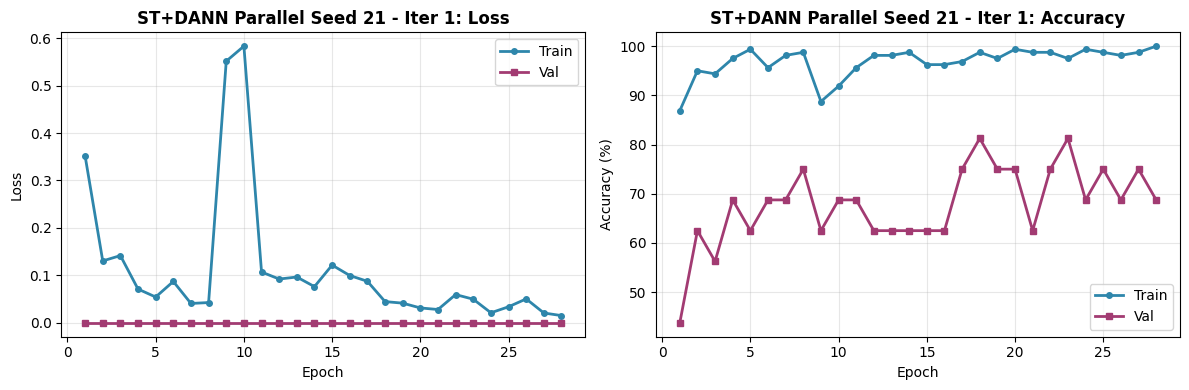

Evaluating Best Model (Seed 21)
Best Iteration: 1
Best Avg Acc: 82.81%
  Source: 84.38%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_finetuned_t90/seed_21/st_dann_iter_1.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         84.38%      0.8485       87.50%       81.25%    0.6874
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    1.3916
-------------------------------------------------------------------------------------


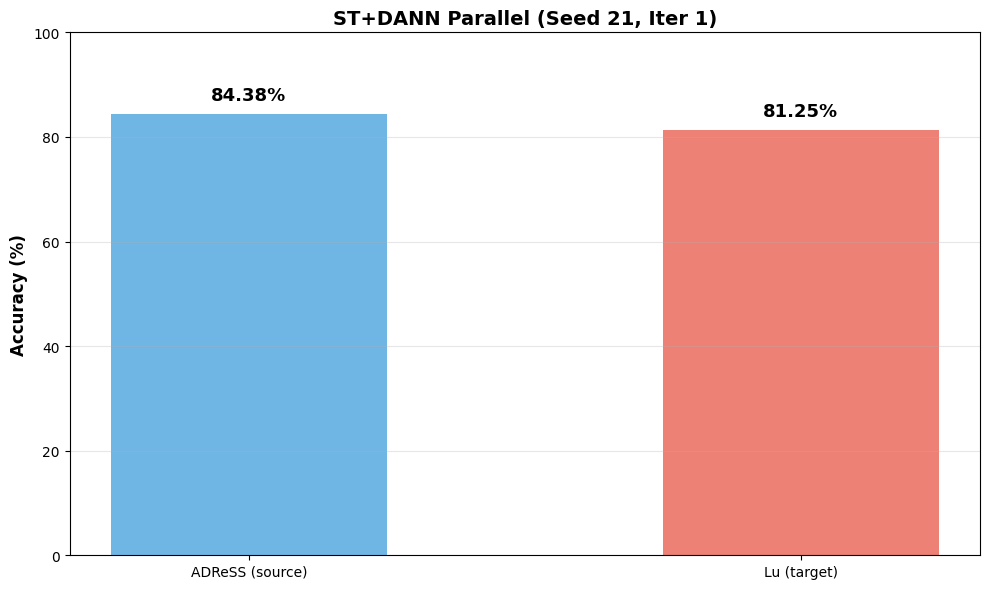

In [11]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 42

In [12]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=42,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 42)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.583 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.792 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.833 | Source Val: 0.500 | Target Val: 0.438 | Avg: 0.469 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.823 | Source Val: 0.531 | Target Val: 0.438 | Avg: 0.484 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  13 | Train: 0.963 | Source Val: 0.719 | Target Val: 0.750 | Avg: 0.734 | Domain: 0.503 | λ_dom: 1.500


Epoch  14 | Train: 0.950 | Source Val: 0.750 | Target Val: 0.688 | Avg: 0.719 | Domain: 0.469 | λ_dom: 1.500


Epoch  15 | Train: 0.950 | Source Val: 0.781 | Target Val: 0.750 | Avg: 0.766 | Domain: 0.519 | λ_dom: 1.500


Epoch  16 | Train: 0.981 | Source Val: 0.719 | Target Val: 0.750 | Avg: 0.734 | Domain: 0.509 | λ_dom: 1.500


Epoch  17 | Train: 0.956 | Source Val: 0.750 | Target Val: 0.688 | Avg: 0.719 | Domain: 0.519 | λ_dom: 1.500
  Early stop at epoch 17
Iter 9 Best: Epoch 7 | Avg:78.12% | Src:75.00% | Tgt:81.25% | Pseudo:49

Best: Iter 0 | Avg:84.38% | Src:87.50% | Tgt:81.25%



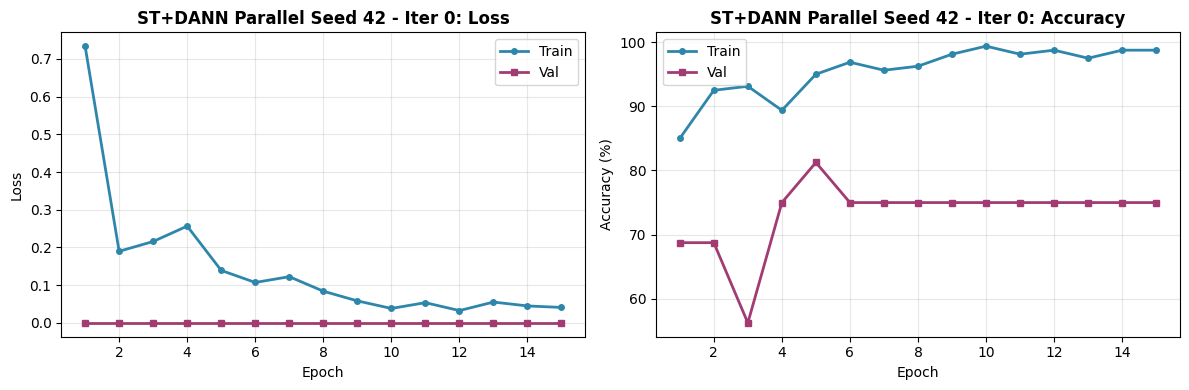

Evaluating Best Model (Seed 42)
Best Iteration: 0
Best Avg Acc: 84.38%
  Source: 87.50%
  Target: 81.25%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_finetuned_t90/seed_42/st_dann_iter_0.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         87.50%      0.8667       81.25%       93.75%    0.5137
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    0.7879
-------------------------------------------------------------------------------------


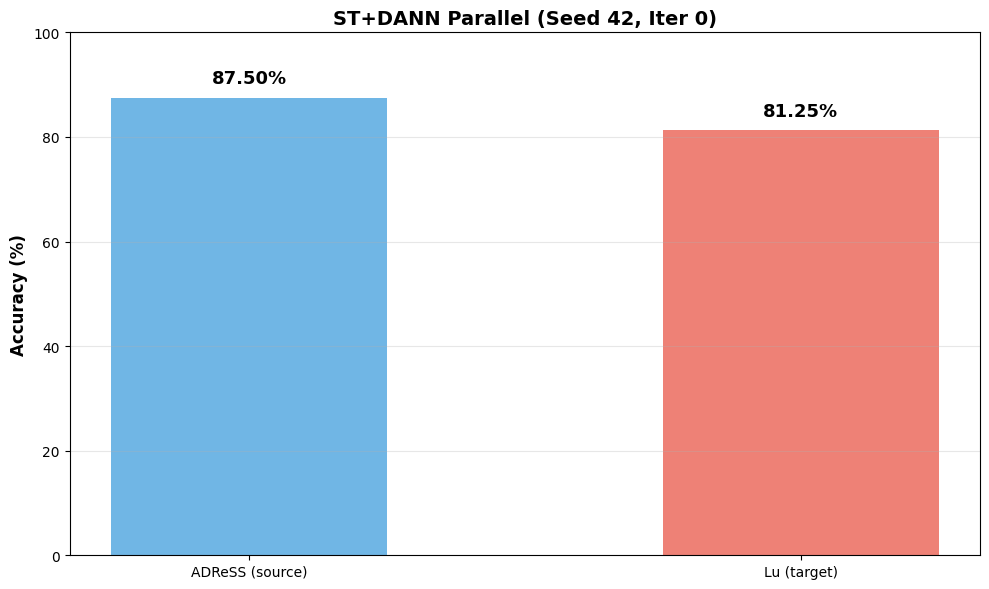

In [13]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 84

In [14]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=84,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 84)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.531 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.750 | Source Val: 0.562 | Target Val: 0.438 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.844 | Source Val: 0.594 | Target Val: 0.438 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.844 | Source Val: 0.750 | Target Val: 0.500 | Avg: 0.625 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  24 | Train: 1.000 | Source Val: 0.750 | Target Val: 0.562 | Avg: 0.656 | Domain: 0.506 | λ_dom: 1.500


Epoch  25 | Train: 0.988 | Source Val: 0.688 | Target Val: 0.625 | Avg: 0.656 | Domain: 0.522 | λ_dom: 1.500


Epoch  26 | Train: 0.956 | Source Val: 0.625 | Target Val: 0.688 | Avg: 0.656 | Domain: 0.522 | λ_dom: 1.500


Epoch  27 | Train: 0.919 | Source Val: 0.719 | Target Val: 0.688 | Avg: 0.703 | Domain: 0.512 | λ_dom: 1.500


Epoch  28 | Train: 0.925 | Source Val: 0.781 | Target Val: 0.562 | Avg: 0.672 | Domain: 0.469 | λ_dom: 1.500
  Early stop at epoch 28
Iter 9 Best: Epoch 18 | Avg:75.00% | Src:81.25% | Tgt:68.75% | Pseudo:46
  → New global best!

Best: Iter 9 | Avg:75.00% | Src:81.25% | Tgt:68.75%



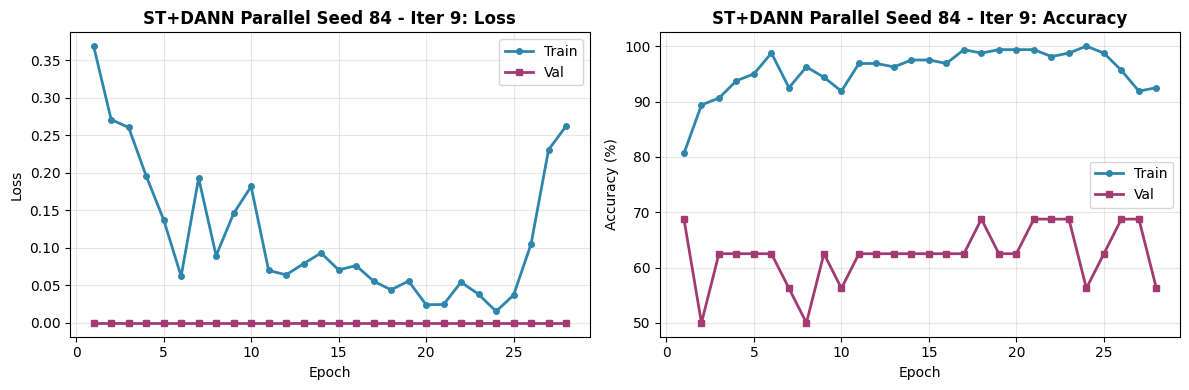

Evaluating Best Model (Seed 84)
Best Iteration: 9
Best Avg Acc: 75.00%
  Source: 81.25%
  Target: 68.75%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_finetuned_t90/seed_84/st_dann_iter_9.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         81.25%      0.8125       81.25%       81.25%    0.6320
Lu (target domain)             68.75%      0.7368       87.50%       50.00%    1.6674
-------------------------------------------------------------------------------------


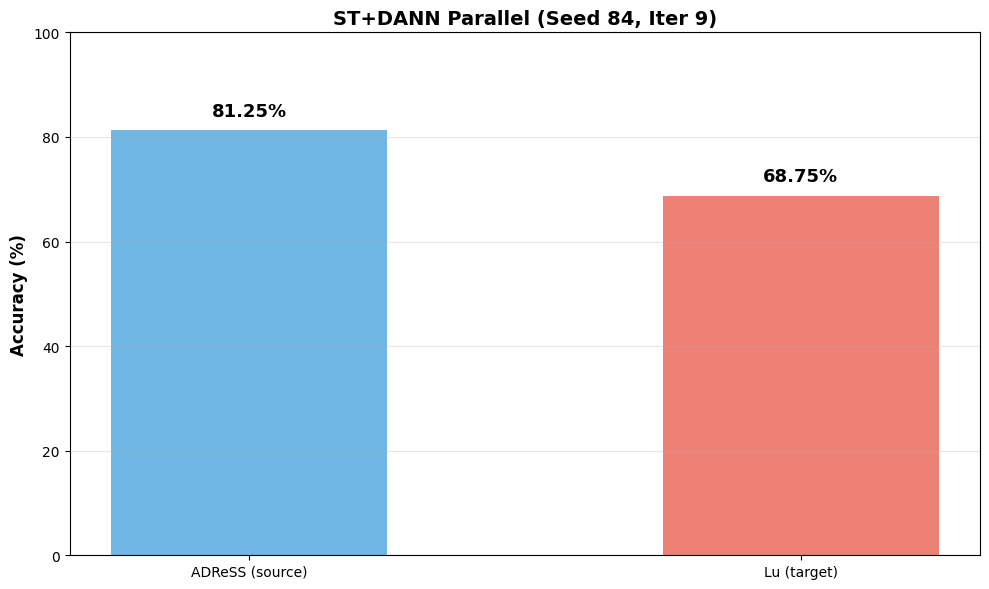

In [15]:
plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 168

In [16]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=168,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 168)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.583 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.698 | Source Val: 0.469 | Target Val: 0.250 | Avg: 0.359 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.865 | Source Val: 0.562 | Target Val: 0.312 | Avg: 0.438 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.844 | Source Val: 0.688 | Target Val: 0.312 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  13 | Train: 0.969 | Source Val: 0.719 | Target Val: 0.625 | Avg: 0.672 | Domain: 0.527 | λ_dom: 1.500


Epoch  14 | Train: 0.984 | Source Val: 0.719 | Target Val: 0.438 | Avg: 0.578 | Domain: 0.551 | λ_dom: 1.500


Epoch  15 | Train: 0.984 | Source Val: 0.750 | Target Val: 0.625 | Avg: 0.688 | Domain: 0.531 | λ_dom: 1.500


Epoch  16 | Train: 0.992 | Source Val: 0.750 | Target Val: 0.688 | Avg: 0.719 | Domain: 0.527 | λ_dom: 1.500


Epoch  17 | Train: 0.984 | Source Val: 0.750 | Target Val: 0.688 | Avg: 0.719 | Domain: 0.469 | λ_dom: 1.500
  Early stop at epoch 17
Iter 9 Best: Epoch 7 | Avg:73.44% | Src:84.38% | Tgt:62.50% | Pseudo:34

Best: Iter 0 | Avg:76.56% | Src:84.38% | Tgt:68.75%



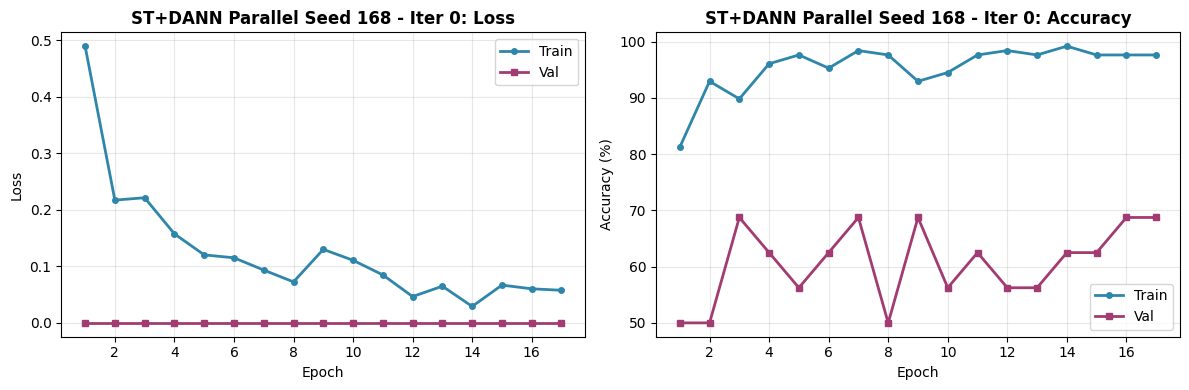

Evaluating Best Model (Seed 168)
Best Iteration: 0
Best Avg Acc: 76.56%
  Source: 84.38%
  Target: 68.75%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_finetuned_t90/seed_168/st_dann_iter_0.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         84.38%      0.8387       81.25%       87.50%    0.4808
Lu (target domain)             68.75%      0.7368       87.50%       50.00%    1.6640
-------------------------------------------------------------------------------------


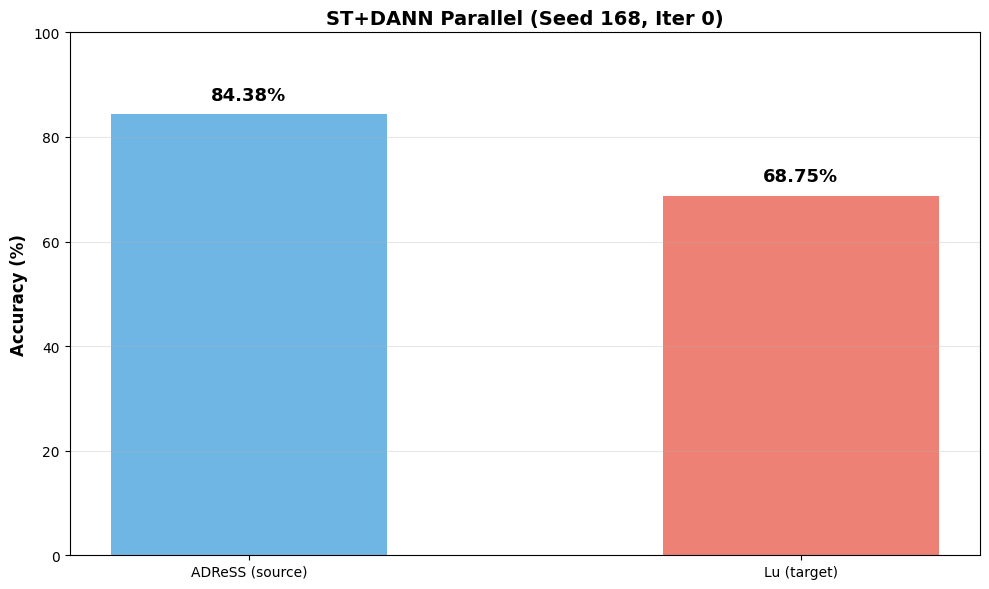

In [17]:

plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

## Seed 336

In [18]:
seed, all_metrics, all_histories, all_pseudo_stats = train_st_dann_parallel(
    seed=336,
    source_train_dataset=source_train_dataset,
    target_train_dataset=target_train_dataset,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    warmup_epochs=WARMUP_EPOCHS,
    max_iterations=MAX_ITERATIONS,
    max_epochs_per_iter=MAX_EPOCHS_PER_ITER,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    min_pseudo_samples=MIN_PSEUDO_SAMPLES,
    domain_warmup_epochs=DOMAIN_WARMUP_EPOCHS,
    domain_anneal_ratio=DOMAIN_ANNEAL_RATIO,
    lambda_class=LAMBDA_CLASS,
    lambda_domain=LAMBDA_DOMAIN,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC,
)

all_results['seeds'].append(seed)
all_results['metrics'].append(all_metrics)
all_results['histories'].append(all_histories)
all_results['pseudo_stats'].append(all_pseudo_stats)

# Find best iteration and plot training curves
best_iter_idx = max(range(len(all_metrics)), key=lambda i: all_metrics[i].get('avg_val_acc', 0) if all_metrics[i] else 0)
best_history = all_histories[best_iter_idx]


ST+DANN Parallel Training (Seed 336)
Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30



WARMUP: Training DANN on source only (20 epochs)


Epoch   1 | Train: 0.615 | Source Val: 0.500 | Target Val: 0.500 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   2 | Train: 0.833 | Source Val: 0.562 | Target Val: 0.438 | Avg: 0.500 | Domain: 0.000 | λ_dom: 0.000


Epoch   3 | Train: 0.865 | Source Val: 0.656 | Target Val: 0.312 | Avg: 0.484 | Domain: 0.000 | λ_dom: 0.000


Epoch   4 | Train: 0.906 | Source Val: 0.656 | Target Val: 0.375 | Avg: 0.516 | Domain: 0.000 | λ_dom: 0.000


...

Epoch  14 | Train: 0.981 | Source Val: 0.656 | Target Val: 0.438 | Avg: 0.547 | Domain: 0.525 | λ_dom: 1.500


Epoch  15 | Train: 0.963 | Source Val: 0.656 | Target Val: 0.375 | Avg: 0.516 | Domain: 0.472 | λ_dom: 1.500


Epoch  16 | Train: 0.969 | Source Val: 0.719 | Target Val: 0.375 | Avg: 0.547 | Domain: 0.431 | λ_dom: 1.500


Epoch  17 | Train: 0.956 | Source Val: 0.750 | Target Val: 0.438 | Avg: 0.594 | Domain: 0.525 | λ_dom: 1.500


Epoch  18 | Train: 0.975 | Source Val: 0.750 | Target Val: 0.438 | Avg: 0.594 | Domain: 0.509 | λ_dom: 1.500
  Early stop at epoch 18
Iter 9 Best: Epoch 8 | Avg:67.19% | Src:78.12% | Tgt:56.25% | Pseudo:39

Best: Iter 0 | Avg:71.88% | Src:75.00% | Tgt:68.75%



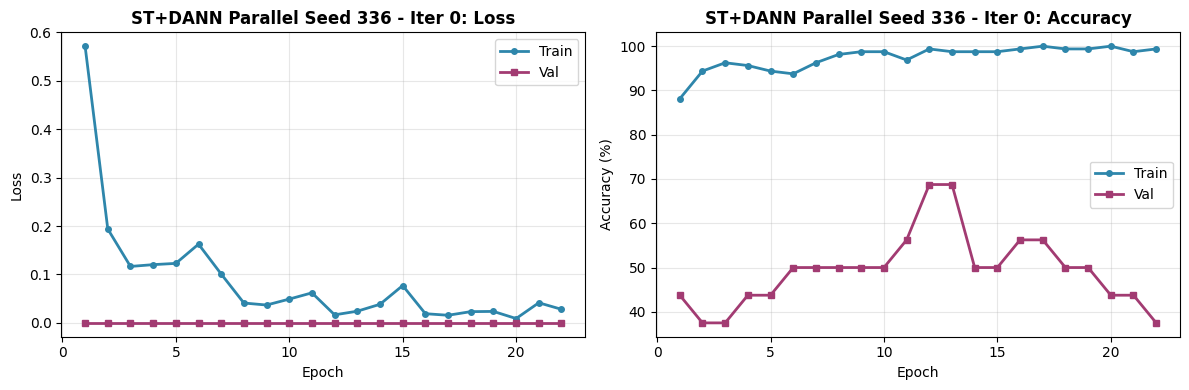

Evaluating Best Model (Seed 336)
Best Iteration: 0
Best Avg Acc: 71.88%
  Source: 75.00%
  Target: 68.75%
Loading model from: /root/autodl-tmp/models/ST_DANN_parallel_ADReSS_to_Lu_xlsr_finetuned_t90/seed_336/st_dann_iter_0.pth

Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
ADReSS (source domain)         75.00%      0.7500       75.00%       75.00%    0.8277
Lu (target domain)             68.75%      0.6667       62.50%       75.00%    2.3841
-------------------------------------------------------------------------------------


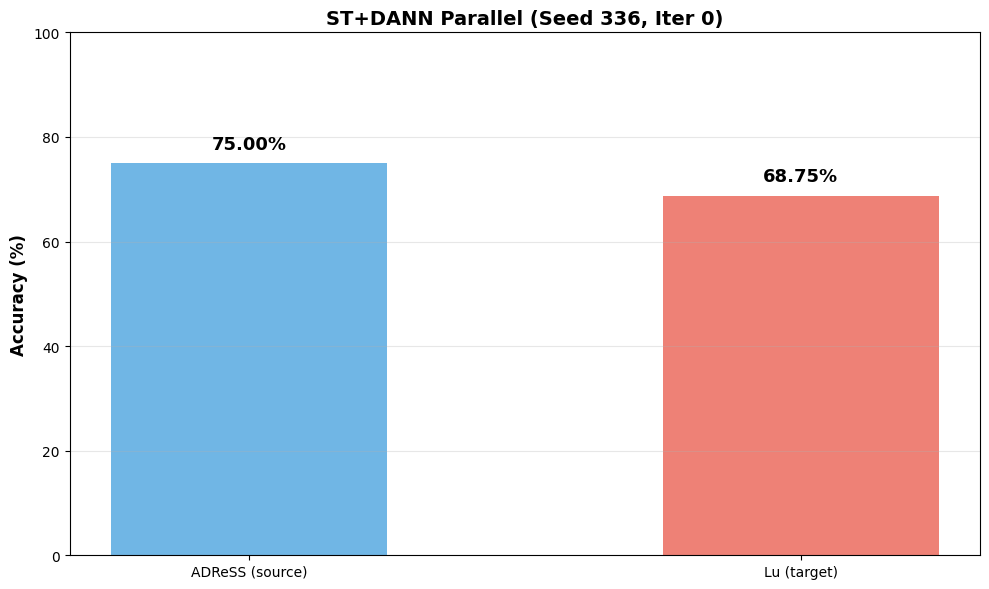

In [19]:

plot_training_curves(
    epochs=best_history['epochs'],
    train_loss=best_history['train_class_losses'],
    val_loss=[0]*len(best_history['epochs']),
    train_acc=best_history['train_accs'],
    val_acc=best_history['target_val_accs'],
    title_prefix=f'ST+DANN Parallel Seed {seed} - Iter {best_iter_idx}'
)

# Evaluate best model
source_metrics, target_metrics = evaluate_and_visualize(
    seed, all_metrics, all_histories, all_pseudo_stats,
    source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)

In [20]:
seeds = all_results['seeds']

# Source domain results
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Target domain results
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"{'Dataset':<25} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{f'{SOURCE_DATASET} (source domain)':<25} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>6.4f}  {np.mean(source_losses):>10.4f}")
print(f"{f'{TARGET_DATASET} (target domain)':<25} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>6.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\n")

print(f"{'Seed':<8} {'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {f'{SOURCE_DATASET} (source domain)':<25} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':8} {f'{TARGET_DATASET} (target domain)':<25} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")

Dataset                   Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
ADReSS (source domain)     82.50% ± 4.24%    0.8233 ± 0.0406      0.6283
Lu (target domain)         73.75% ± 6.12%    0.7575 ± 0.0597      1.5790
------------------------------------------------------------------------------------------

Seed     Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       ADReSS (source domain)         84.38%      0.8485       87.50%       81.25%    0.6874
         Lu (target domain)             81.25%      0.8235       87.50%       75.00%    1.3916
------------------------------------------------------------------------------------------
42       ADReSS (source domain)         87.50%      0.8667       81.25%       93.75%    0.5137
         Lu (target do